# **Title: Week 8 Assignment**

---



**Submitted by:** Banu Boopalan

**Date:** 03/26/25

**Course:** Data Science – DATA620

**Video Link:** https://youtu.be/e1tIq0pNLg8

**Github Repository:https://github.com/BanuB/CUNY-DATA-620-WebAnalytics/blob/main/Week%208/Week8_Assignment.ipynb

#**Assignment Overview**



Assignment – High Frequency Words

Please answer the following questions in an IPython Notebook, posted to GitHub.
1. Choose a corpus of interest.
2. How many total unique words are in the corpus? (Please feel free to define unique words in any interesting,
defensible way).
3. Taking the most common words, how many unique words represent half of the total words in the corpus?
4. Identify the 200 highest frequency words in this corpus.
5. Create a graph that shows the relative frequency of these 200 words.
6. Does the observed relative frequency of these words follow Zipf’s law? Explain.
7. In what ways do you think the frequency of the words in this corpus differ from “all words in all corpora.”

**PERSUADE 2.0 Corpus dataset**

PERSUADE 2.0
This dataset was created by The Learning Agency and Vanderbilt University, originally pulled from here: https://github.com/scrosseye/persuade_corpus_2.0. More info from TLA about the dataset is available here.

url: https://www.kaggle.com/datasets/nbroad/persaude-corpus-2/data
Citation : Bellow Description from Kaggle URL above

"The PERSUADE 2.0 corpus builds on the PERSUADE 1.0 corpus by providing holistic essay scores to each persuasive essay in the PERSUADE 1.0 corpus as well as proficiency scores for each argumentative and discourse element found in the initial corpus. This version also contains all essays (as compared to 1.0 which linked the training set for the Kaggle competition)

In total, the PERSUADE 2.0 corpus comprises over 25,000 argumentative essays produced by 6th-12th grade students in the United States for 15 prompts on two writing tasks: independent and source-based writing. The PERSUADE 2.0 corpus provides detailed individual and demographic information for each writer as well as the initial annotations for argumentative and discourse element found PERSUADE 1.0.
License
(see here) CC BY-NC-SA 4.0 DEED Attribution-NonCommercial-ShareAlike 4.0 International license (https://creativecommons.org/licenses/by-nc-sa/4.0/deed.en)"






**BLOCK1: Read the Dataset**

In [260]:
import pandas as pd

# Read the persuade_2.0.csv file into a DataFrame
file_path = r'C:\Users\Banu\Documents\GitHub\CUNY-DATA-620-WebAnalytics\Week 8\persuade_2.0_human_scores_demo_id_github.csv'  # Update this with the actual path to your CSV file
df = pd.read_csv(file_path)

print(df.head())



  essay_id_comp                                          full_text  \
0  423A1CA112E2  Phones\n\nModern humans today are always on th...   
1  BC75783F96E3  This essay will explain if drivers should or s...   
2  74C8BC7417DE  Driving while the use of cellular devices\n\nT...   
3  A8445CABFECE  Phones & Driving\n\nDrivers should not be able...   
4  6B4F7A0165B9  Cell Phone Operation While Driving\n\nThe abil...   

   holistic_essay_score  word_count         prompt_name         task  \
0                     3         378  Phones and driving  Independent   
1                     4         432  Phones and driving  Independent   
2                     2         179  Phones and driving  Independent   
3                     3         221  Phones and driving  Independent   
4                     4         334  Phones and driving  Independent   

                                          assignment source_text gender  \
0  Today the majority of humans own and operate c...         NaN      M

In [261]:
df.essay_id_comp.size
df.word_count.describe()
df.holistic_essay_score.describe()



count    25996.000000
mean         3.315010
std          1.160473
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          6.000000
Name: holistic_essay_score, dtype: float64

In [262]:
import requests
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
# Download the NLTK stopwords if you don't have them yet
nltk.download('stopwords')

# Filter the DataFrame for gender as female
female_corpus = df[df['gender'] == 'F']['full_text'].tolist()

# Filter the DataFrame for gender as male
male_corpus = df[df['gender'] == 'M']['full_text'].tolist()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Banu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [263]:
from IPython.display import display
# Create a DataFrame from the female_corpus
female_corpus_df = pd.DataFrame(female_corpus, columns=['Full Text'])
display(female_corpus_df.head())

,Full Text
0,Driving while the use of cellular devices\n\nT...
1,Should drivers be able to be on their phone wh...
2,Everyone knows that texting and driving is a t...
3,Operating a motor vehicle while on your cell p...
4,Should Drivers Be Allowed To Use Cell Phones W...


In [264]:
male_corpus_df = pd.DataFrame(male_corpus, columns=['Full Text'])
display(male_corpus_df.head())

,Full Text
0,Phones\n\nModern humans today are always on th...
1,This essay will explain if drivers should or s...
2,Phones & Driving\n\nDrivers should not be able...
3,Cell Phone Operation While Driving\n\nThe abil...
4,Cell phone use should not be legal while drivi...


FEMALECORPUS: Initially clean up female records and corpus

In [265]:
from IPython.display import display, HTML

# Load the list of stopwords from NLTK
stop_words = set(stopwords.words('english'))

# Clean and tokenize the text, converting it to lowercase
femalecorpuswords = re.findall(r'\b\w+\b', ' '.join(female_corpus).lower())

# Print the first few cleaned and tokenized words
print("\nFirst few cleaned and tokenized words:")
print(femalecorpuswords[:10])

filtered_words1 = [word for word in femalecorpuswords if word not in stop_words]

# Count word frequencies
female_counts = Counter(filtered_words1)
unique_words = len(female_counts)
display(HTML(f"Total unique words (excluding stop words): {unique_words}"))




First few cleaned and tokenized words:
['driving', 'while', 'the', 'use', 'of', 'cellular', 'devices', 'today', 'most', 'of']


MALECORPUS: Initially let's explore using wordcloud, but these words are not as unique

In [266]:
# Clean and tokenize the text, converting it to lowercase
malecorpuswords = re.findall(r'\b\w+\b', ' '.join(male_corpus).lower())

# Print the first few cleaned and tokenized words
print("\nFirst few cleaned and tokenized words:")
print(malecorpuswords[:10])

# Filter out stop words from the list
filtered_words = [word for word in malecorpuswords if word not in stop_words]

# Count word frequencies
male_counts = Counter(filtered_words)

# Output the results
unique1_words = len(male_counts)
# Print the result in large font using HTML
display(HTML(f"Total unique words (excluding stop words): {unique1_words}"))




First few cleaned and tokenized words:
['phones', 'modern', 'humans', 'today', 'are', 'always', 'on', 'their', 'phone', 'they']


There are 13,142 text entries (e.g., essays) written by female participants in the dataset.
There are 12,854 text entries (e.g., essays) written by female participants in the dataset.


In [267]:
len(male_corpus)
len(female_corpus)


13142

In [268]:
len(set(word.lower() for word in filtered_words if word.isalpha()))

45893

In [269]:
len(filtered_words)
wordnopunno=[word.lower() for word in filtered_words if word.isalpha()]
tf1=len(wordnopunno)
tf1


2463355

Identify the 200 Highest frequency words in the Male Corpus

In [270]:
fdistmale = nltk.FreqDist(wordnopunno).most_common()
fdistmale[:10]

[('students', 43754),
 ('would', 35464),
 ('people', 32461),
 ('school', 27714),
 ('could', 19988),
 ('get', 19716),
 ('like', 18038),
 ('one', 17778),
 ('help', 16735),
 ('time', 16633),
 ('also', 16597),
 ('student', 16365),
 ('make', 15188),
 ('car', 14546),
 ('think', 14483),
 ('cars', 13914),
 ('many', 13193),
 ('work', 12224),
 ('good', 11303),
 ('driving', 11207),
 ('even', 11107),
 ('want', 10519),
 ('venus', 10464),
 ('way', 10072),
 ('better', 10042),
 ('use', 9760),
 ('know', 9709),
 ('go', 9232),
 ('need', 9202),
 ('take', 9091),
 ('home', 8767),
 ('may', 8730),
 ('able', 8703),
 ('project', 8263),
 ('teacher', 8246),
 ('summer', 8135),
 ('electoral', 7855),
 ('something', 7824),
 ('life', 7649),
 ('things', 7521),
 ('learning', 7509),
 ('class', 7495),
 ('projects', 7480),
 ('phones', 7470),
 ('new', 7395),
 ('teachers', 7302),
 ('college', 7256),
 ('phone', 7156),
 ('face', 7022),
 ('see', 7008),
 ('online', 7003),
 ('might', 6961),
 ('classes', 6925),
 ('going', 6894),
 

MaleCorpus: Defining most unique words as those appearing of frequency btween 1 and 10 and a Wordcloud of most unique words

In [271]:
# Define the frequency range
min_freq = 1
max_freq = 10

# Create a dictionary of words with frequencies in the specified range
filtered_fdistmale = {word: freq for word, freq in fdistmale  if min_freq <= freq <= max_freq}

# Display the first 10 entries in the filtered dictionary
print("Filtered dictionary of words with frequency between 1 and 10:")
print(dict(list(filtered_fdistmale.items())[:10]))

t2d= dict(list(filtered_fdistmale.items()))

Filtered dictionary of words with frequency between 1 and 10:
{'carelessness': 10, 'deemed': 10, 'debris': 10, 'arizona': 10, 'permits': 10, 'audio': 10, 'minuets': 10, 'susceptible': 10, 'montana': 10, 'protective': 10}


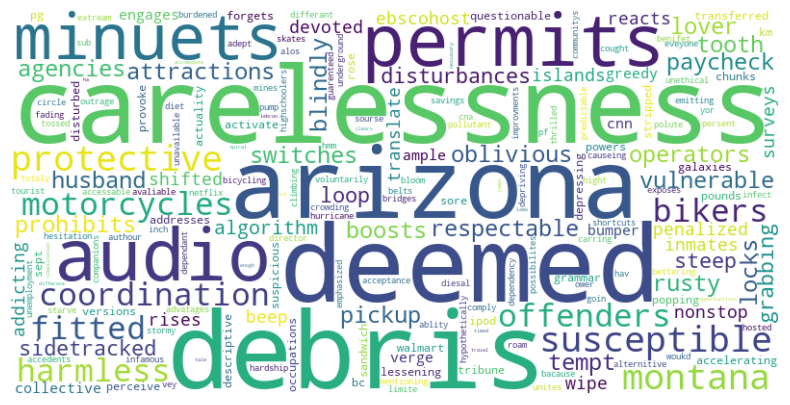

In [272]:
# Generate word cloud
wordcloud4 = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(t2d)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud4, interpolation='bilinear')
plt.axis('off')  # Hide the axes
plt.show()

In [273]:
femword=[word.lower() for word in filtered_words1 if word.isalpha()]
tf2=len(femword)
tf2

2752586

For the Analysis for this project, review only the Female Corpus dataset

2.  How many total unique words are in the corpus? (Please feel free to define unique words in any interesting, defensible way). ANSWER: There are total 45075 unique words in the female corpus 

4. Identify the 200 Highest frequency words in the Female Corpus, Create a graph that shows the relative frequency of the 200 words #

5. Create a graph that shows the relative frequency of these 200 words.

In [274]:
# Calculate the total number of unique words in the femword corpus
unique_words_count = len(set(femword))
unique_words_count 

45075

In [275]:
fdistfemale = nltk.FreqDist(femword).most_common()
fdistfemale[:10]

[('students', 52114),
 ('would', 37600),
 ('people', 34230),
 ('school', 30778),
 ('could', 20979),
 ('get', 20545),
 ('help', 19235),
 ('time', 18679),
 ('like', 18438),
 ('also', 17938)]

In [276]:
cumulative = 0.0
freqlistfem = nltk.FreqDist(femword)

# Get the top 200 most common words directly from fdistfemale
most_common_words = [word for (word, count) in freqlistfem.most_common(200)]

# Iterate through the most common words and calculate cumulative frequency
for rank, word in enumerate(most_common_words[:25]):
    cumulative += freqlistfem.freq(word)
    print("%3d %6.2f%% %s" % (rank + 1, cumulative * 100, word))
    if cumulative > 0.25:  # Stop if cumulative frequency exceeds 25%
        break

  1   1.89% students
  2   3.26% would
  3   4.50% people
  4   5.62% school
  5   6.38% could
  6   7.13% get
  7   7.83% help
  8   8.51% time
  9   9.18% like
 10   9.83% also
 11  10.47% one
 12  11.10% car
 13  11.70% student
 14  12.29% many
 15  12.88% think
 16  13.46% cars
 17  14.05% make
 18  14.51% work
 19  14.97% even
 20  15.41% venus
 21  15.84% know
 22  16.27% good
 23  16.69% want
 24  17.10% may
 25  17.52% way


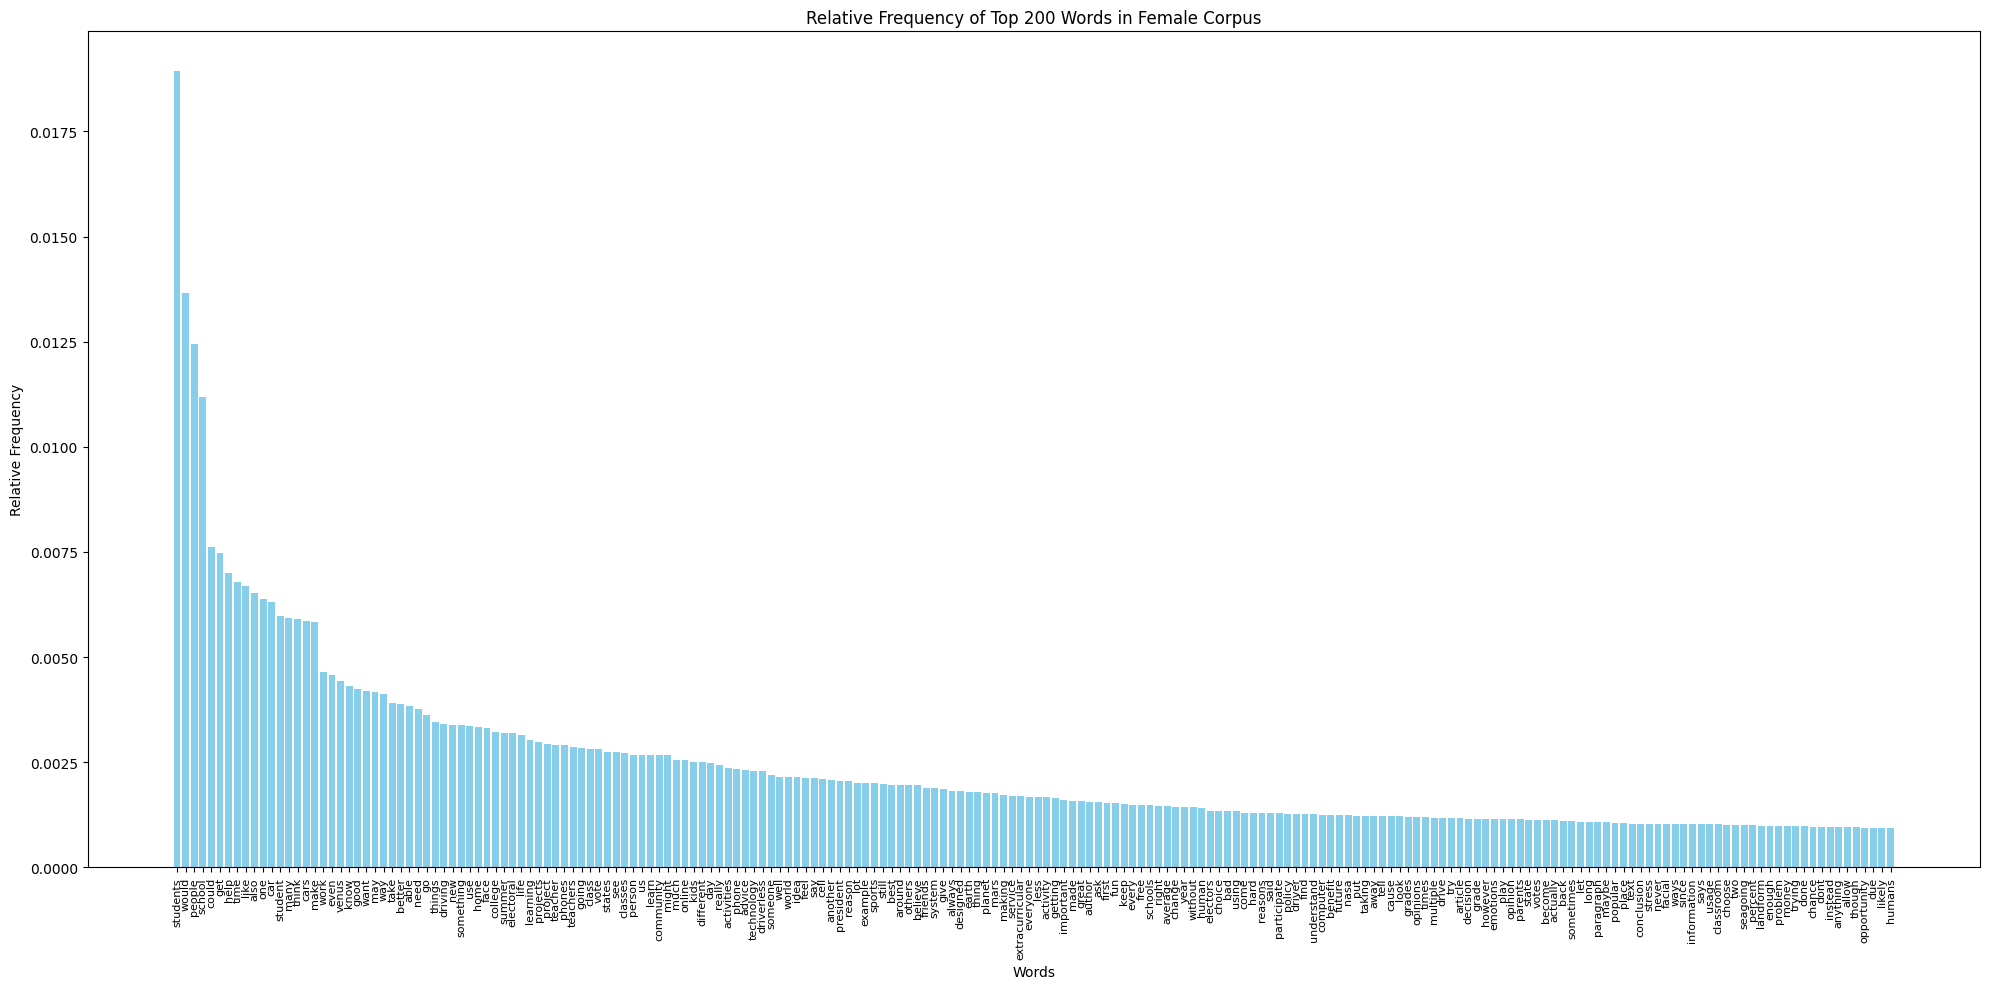

In [277]:
# Get the top 200 most common words and their counts
most_common_words = freqlistfem.most_common(200)

total_count = sum(freqlistfem.values())

words = [word for word, count in most_common_words]
relative_frequencies = [count / total_count for _, count in most_common_words]

# Plot the relative frequencies
plt.figure(figsize=(20, 10))  # Increase figure size for better readability
plt.bar(range(len(words)), relative_frequencies, color='skyblue')
plt.xticks(range(len(words)), words, rotation=90, fontsize=8)  # Rotate labels for readability
plt.xlabel("Words")
plt.ylabel("Relative Frequency")
plt.title("Relative Frequency of Top 200 Words in Female Corpus")
plt.tight_layout()
plt.show()

FemaleCorpus: Defining most unique words (words whose frequency is lower) as those appearing of frequency btween 1 and 10 and a Wordcloud of most unique words 

In [278]:
# Define the frequency range
min_freq = 1
max_freq = 10

# Create a dictionary of words with frequencies in the specified range
filtered_fdistfemale = {word: freq for word, freq in fdistfemale if min_freq <= freq <= max_freq}

# Display the first 10 entries in the filtered dictionary
print("Filtered dictionary of words with frequency between 1 and 10:")
print(dict(list(filtered_fdistfemale.items())[:10]))

t1d= dict(list(filtered_fdistfemale.items()))

Filtered dictionary of words with frequency between 1 and 10:
{'traumatic': 10, 'glancing': 10, 'deter': 10, 'ignorance': 10, 'procedures': 10, 'clicking': 10, 'holders': 10, 'philadelphia': 10, 'impaired': 10, 'forbidding': 10}


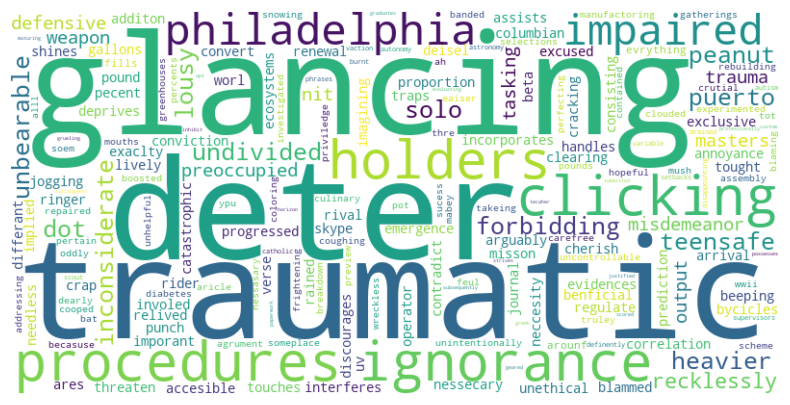

In [279]:
# Generate word cloud
wordcloud3 = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(t1d)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud3, interpolation='bilinear')
plt.axis('off')  # Hide the axes
plt.show()

3. FemaleCorpus: Number of unique words representing half of the total words #

Total Words in the Corpus: 2,752,586:

Number of Unique Words Representing Half of the Total Words: 217:

We have identified that 217 unique words account for half of the total word count (i.e., 1,376,293 words).This indicates that a small subset of the most frequent words dominates the corpus, which is typical in natural language due to Zipf's Law which states that word frequency of words in a frequency table is inversely propotional to word rank. It was found that the most common words occurs approximately twice as often as the next common one, three times as often as the 3rd most common one etc..

words_that_represent_half:

The first few words in this list such as Students, people , school etc.. (words_that_represent_half[:25]) are the most frequent words in the corpus.
The last few words in this list such as  'instead', 'anything', 'opportunity',(words_that_represent_half[-25:]) are the least frequent words that contribute to the half of the total word count.




In [280]:
total_words = len(femword)
total_words

2752586

In [281]:

total_words = len(femword)
fdistfemalenew = nltk.FreqDist(femword)
sorted_words = sorted(fdistfemalenew.items(), key=lambda x: x[1], reverse=True)

# Calculate how many unique words represent half of the total words
half_total = total_words / 2
running_total = 0
unique_word_count = 0
words_that_represent_half = []

for word, freq in sorted_words:
    running_total += freq
    unique_word_count += 1
    words_that_represent_half.append(word)
    if running_total >= half_total:
        break

# Display the results
print(f"Total words in the corpus: {total_words}")
print(f"Number of unique words representing half of the total words: {unique_word_count}")
words_that_represent_half[:25]


Total words in the corpus: 2752586
Number of unique words representing half of the total words: 217


['students',
 'would',
 'people',
 'school',
 'could',
 'get',
 'help',
 'time',
 'like',
 'also',
 'one',
 'car',
 'student',
 'many',
 'think',
 'cars',
 'make',
 'work',
 'even',
 'venus',
 'know',
 'good',
 'want',
 'may',
 'way']

In [282]:
words_that_represent_half[-25:]

['instead',
 'anything',
 'allow',
 'though',
 'opportunity',
 'due',
 'likely',
 'humans',
 'break',
 'used',
 'end',
 'dear',
 'election',
 'makes',
 'attention',
 'air',
 'principal',
 'big',
 'road',
 'distance',
 'show',
 'environment',
 'point',
 'program',
 'sure']

6. Does the observed relative frequency of these words follow Zipf’s law? Explain. #


While the result shows that a small number of words (217 out of all unique words) are used very frequently, the cumulative frequency calculated show the following % on the rank. So, basically by zipf's law , the frequency of the 2nd ranked word (would) should be approx 1/2 that of the 1st ranked word (students), but this is not the case, also the distribution is relatively close of the top 10 words, therefore it is much flatter than what Zipf law generally predicts.  On the graph below, At the beginning (low ranks, high frequencies), the observed frequencies (blue line) are higher than the predicted frequencies (red dashed line). This could indicate that the most frequent words are more dominant than Zipf's Law predicts. This is due to nature of the corpus, since the corpus is essays basically based on specific topic such as driving with phones etc..
Rank, cumulative, word
1   1.89% students
2   3.26% would
3   4.50% people
4   5.62% school
5   6.38% could



7. In what ways do you think the frequency of the words in this corpus differ from “all words in all corpora.” 

We have high frequency of words  that are low ranks are more dominant than the zipf's law. We also removed stop words. This is shown by the blue line higher than the red dashed line at the top.  In all words in all corpora, the high frequency words are not as pronounced due to corpus being more diverse and range of contexts. This corpus is more narrower and essay oriented so certain words are more widely used and often used. Corpus size is also small and this can play a role in the frequency analysis. The variation on context is also low since these are argumentative essays of 8-12 grade students  



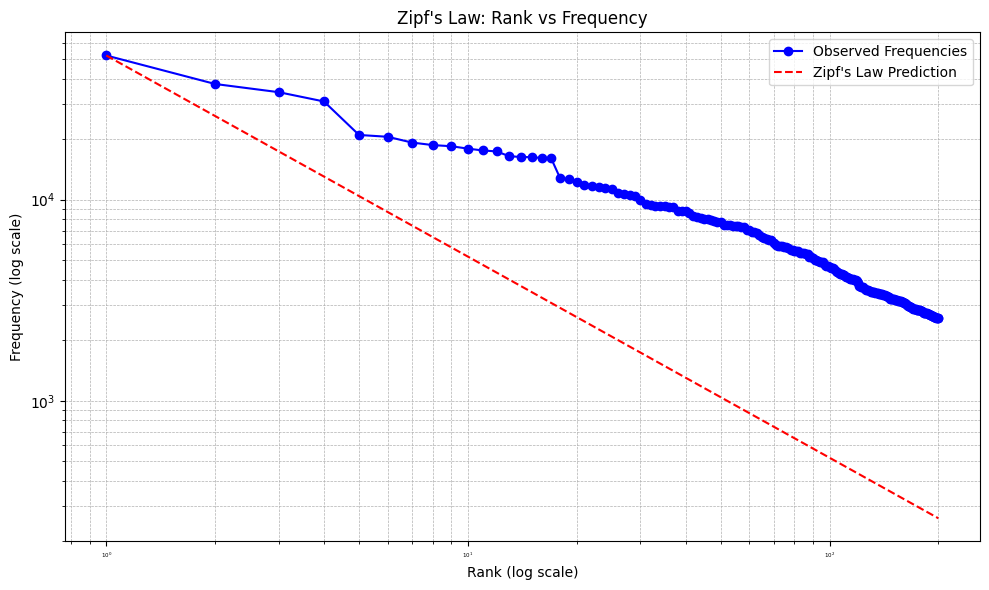

In [283]:
import numpy as np
import matplotlib.pyplot as plt

# Get the ranks and frequencies of the top 200 words
ranks = np.arange(1, len(most_common_words) + 1)  
frequencies = [count for _, count in most_common_words]

plt.figure(figsize=(10, 6))
plt.loglog(ranks, frequencies, marker="o", label="Observed Frequencies", color="blue")

zipf_frequencies = [frequencies[0] / rank for rank in ranks]  
plt.loglog(ranks, zipf_frequencies, linestyle="--", label="Zipf's Law Prediction", color="red")

# Add labels and legend
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Zipf's Law: Rank vs Frequency")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()